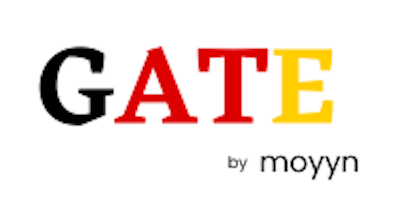

## Analysis on customer data from an e-learning company

----

## SUMMARY

1. [Data Preparation](#1)
2. [Lifecycle Stage (Target Variable)](#2)
3. [Explore the Content of the Other Variables](#3)
4. [Analysis of Recent Conversion Data](#4)
5. [Data Preprocessing](#5)
6. [Classification Analysis](#6)

----

<a id="1"></a>
# 1. Data Preparation

## 1.1 Load the Data

In [ ]:
# Load the modules
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import pyplot
from matplotlib.colors import ListedColormap
import plotly
import plotly.express as px

import sklearn 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score,classification_report,precision_score
from sklearn.metrics import recall_score,f1_score,confusion_matrix
from sklearn.preprocessing import LabelEncoder,MinMaxScaler,StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
from xgboost import XGBClassifier

from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score,davies_bouldin_score
from sklearn.cluster import AgglomerativeClustering

import warnings
warnings.filterwarnings("ignore")

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
# Read the data and display the dataset
crm_df = pd.read_excel('/kaggle/input/d/kavithachetanadidugu/crm-cleaned-data/CRM_Cleaned_Data_v1.xlsx')

crm_df.head()        

In [ ]:
print('The dataset has {} rows and {} columns.'.format(crm_df.shape[0],crm_df.shape[1]))

## 1.2 Remove null entries and drop useless columns

In [ ]:
# No. of null data per column
crm_df.isnull().sum()

<div class="alert alert-block alert-warning"> 📌 Several features, like 'Batch', have NaN values.
Other columns, like 'Batch' and 'Batch choice', have the same meaning and need to be merged.</div>

In [ ]:
# Merge 'Batch' and 'Batch choice' columns properly
crm_df['Batch'].fillna(crm_df['Batch choice'],inplace = True)

# Now drop 'Batch choice' column
crm_df = crm_df.drop(['Batch choice'],axis=1)

file0 = crm_df.groupby('Record ID')['Record ID'].count().reset_index(name='count').sort_values(['count'],ascending=False).head(10)
file0

Record ID has only single entries. It can be dropped.

In [ ]:
crm_df = crm_df.drop(['Record ID'],axis=1)

1. Substitute NaN values in the 'University Name' column with 'NO'.
2. Rename the column. New meaning: did/didn't go to the university.
3. Substitute university names with 'YES'.

In [ ]:
# If 'University Name' = NaN --> 'None'
crm_df['College/University Name'].fillna('NO',inplace=True)

# Rename the column
crm_df.rename(columns={"College/University Name": "Went to the University?"},inplace=True)

crm_df.loc[crm_df['Went to the University?'] != 'NO','Went to the University?'] = 'YES'

crm_df.groupby('Went to the University?')['Went to the University?'].count().reset_index(name='count').sort_values(['count'], ascending= False).head(10)

<div class="alert alert-block alert-warning"> 📌 Column 'Country/Region' is problematic: some country names are missing, others are not written in latin characters. <br>
Example: </div>
    

In [ ]:
print('\n Arabic:',crm_df['Country/Region'][83],'\n Not written in Latin characters.')

In [ ]:
# Solution: drop the column and read country names from column 'IP Country'
crm_df = crm_df.drop(['Country/Region'],axis=1)

# Also drop 'IP State Code/Region Code' and 'IP State/Region' and 'Record ID' columns
crm_df = crm_df.drop(['IP State Code/Region Code','IP State/Region'],axis=1)
crm_df = crm_df.drop(['Number of event completions'],axis=1)

# In column 'IP City', substitute null values with 'unknown'
crm_df['IP City'].fillna('unknown',inplace = True)

# Drop 'Mobile Phone Number' column
crm_df = crm_df.drop(['Mobile Phone Number'],axis=1)

# Drop 'IP Country Code' column
crm_df = crm_df.drop(['IP Country Code'],axis=1)

# Drop 'IP Timezone' column
crm_df = crm_df.drop(['IP Timezone'],axis=1)

In [ ]:
# Drop null values in 'IP Country' column
crm_df.dropna(subset=['IP Country'], inplace=True)

# Substitute NaN with '0' in columns 'Marketing emails clicked', 'Marketing emails delivered' and 
# 'Marketing emails opened'
crm_df['Marketing emails clicked'].fillna(0,inplace = True)
crm_df['Marketing emails delivered'].fillna(0,inplace = True)
crm_df['Marketing emails opened'].fillna(0,inplace = True)

# Substitute NaN with 'N/A' in column 'Referral'
crm_df['Referral'].fillna('N/A',inplace = True)

# Substitute NaN with 'Unknown' in column 'Payment timeline'
crm_df['Payment timeline'].fillna('Unknown',inplace = True)

Solve problems with the 'Payment preference' and 'Payment preference (v4)' colums.

In [ ]:
# Merge 'Payment preference' and 'Payment preference (v4)' columns properly
crm_df['Payment preference'].fillna(crm_df['Payment preference (v4)'],inplace = True)

# Now drop 'Payment preference (v4)' column
crm_df = crm_df.drop(['Payment preference (v4)'],axis=1)

# Substitute extra 'Payment preference' null values with 'Unknown'
crm_df['Payment preference'].fillna('Unknown',inplace = True)

Should I use the column 'City' or 'IP City'?

In [ ]:
city_count = crm_df.groupby('City')['City'].count().reset_index(name='count').sort_values(['count'], ascending= False).head(10)
ip_city_count = crm_df.groupby('IP City')['IP City'].count().reset_index(name='count').sort_values(['count'], ascending= False).head(10)

print(city_count,'\n \n',ip_city_count)

The two column entries do not coincide. The 'IP City' column has many unknown entries. I will drop it.

In [ ]:
crm_df = crm_df.drop(['IP City'],axis=1)

# Check: No. of null data per column
crm_df.isnull().sum()

<div class="alert alert-block alert-success"> 📌 There are no null entries now. Well done! </div>

<a id="2"></a>
# 2. Lifecycle Stage (Target Variable)

Lifecycle stages are used to track how contacts or companies move forward in your process. 
This is the most important variable of the dataframe: it shows whether the contact person is a *lead* or a *subscriber*.

For those who are not native English speakers (I am not one), this should be the difference between these terms:
1. A lead is a contact who has shown some level of interest or engagement with your business, usually by taking a specific action that indicates their potential as a prospective customer. This action might include signing up for a newsletter, downloading a resource, or filling out a contact form. A lead is considered a potential customer and is typically in the early stages of the sales or conversion funnel.

2. A subscriber specifically refers to a contact who has explicitly opted-in to receive email communications from your business. They have given their consent to receive updates, promotions, newsletters, or other types of email content. Subscribers have actively shown interest in staying connected with your brand and are more likely to engage with your email campaigns.

<div class="alert alert-block alert-info"> 📌 If I am correct, the goal of the company would be to turn subscribers into leads and then leads into customers. Something like that.</div>

In [ ]:
life_cycle = crm_df.groupby('Lifecycle Stage')['Lifecycle Stage'].count().reset_index(name='count').sort_values(['count'],ascending= False)

life_cycle

In [ ]:
def label_function(val):
    return f'{val:.0f}%'

labels = ['Lead','Subscriber']

life_cycle.plot(x='Lifecycle Stage',y='count',kind='pie',autopct=label_function,
                textprops={'fontsize':15},labels=labels,colors=['g','gold'])

plt.ylabel('')
plt.title('GATE: Leads and Subscribers',fontsize=20)

plt.tight_layout()

<a id="3"></a>
# 3. Explore the Content of the Other Variables

## 3.1 Customers' Job, Education Level and Country of Origin

First, I am exploring the type of customers' job, the customers' education level and their country of origin.

In [ ]:
job_count = crm_df.groupby('Are you a student/working professional?')['Are you a student/working professional?'].count().reset_index(name='count').sort_values(['count'], ascending= False).head(10)
went_to_university = crm_df.groupby('Went to the University?')['Went to the University?'].count().reset_index(name='count').sort_values(['count'], ascending= False).head(10)

fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(14,6))

ax1.bar(data=job_count,x='Are you a student/working professional?',height='count')
ax2.bar(data=went_to_university,x='Went to the University?',height='count')

ax1.set_title("Customers' Job Types",fontsize=20)
ax1.set_ylabel("count",fontsize=16)
ax1.set_xticklabels(ax1.get_xticklabels(),rotation=45);
ax2.set_title("Went to the University?",fontsize=20)
ax2.set_ylabel("count",fontsize=16)

plt.tight_layout()
plt.show()

In [ ]:
# Number countries in the dataframe
countries = crm_df['IP Country'].value_counts()
print('No. countries in the dataframe: {}\n'.format(len(countries)))

These are the customers' main countries of origin:

In [ ]:
customers_country = crm_df.groupby('IP Country')['IP Country'].count().reset_index(name='count').sort_values(['count'], ascending= False).head(120)

fig = px.choropleth(customers_country,locations='IP Country',locationmode='country names',
                    color='count',  # we indicate the year we are interested in
                    hover_name='IP Country',title = "Customers' Country of Origin on a Scale of Blues",
                    color_continuous_scale='blues')

# Adjusting map, legend, title placement
fig.update_layout(autosize=False,width=1200,height=600,margin=dict(l=50,r=50,b=100,t=100,pad=4),
    template='seaborn',paper_bgcolor="rgb(255, 255, 255)",
    legend=dict(orientation="v",yanchor="auto",y=1,xanchor="right",x=1))

fig.show()

Now, let's see how these variables are related to the life cycle.

First, we are checking what are the main countries for leads and subscribers.

In [ ]:
life_cycle_subs = crm_df.groupby(['Lifecycle Stage','IP Country'])['IP Country'].count().reset_index(name="Country of origin count").sort_values(["Country of origin count",'Lifecycle Stage'],ascending= False).head(5)
life_cycle_leads = crm_df[crm_df['Lifecycle Stage'] == 'Lead'].groupby(['Lifecycle Stage','IP Country'])['IP Country'].count().reset_index(name="Country of origin count").sort_values(["Country of origin count",'Lifecycle Stage'],ascending= False).head(5)

frames = [life_cycle_subs,life_cycle_leads]

life_cycle = pd.concat(frames)
life_cycle

These are the main jobs for leads and subscribers.

In [ ]:
life_cycle_job = crm_df.groupby(['Lifecycle Stage','Are you a student/working professional?'])['Are you a student/working professional?'].count().reset_index(name="Customer's job count").sort_values(['Lifecycle Stage',"Customer's job count"],ascending= False)

life_cycle_job

## 3.2 Average Pageviews, Marketing Emails Opened, Number of Form Submissions & Number of Sessions

These features can be very important to the company that owns the data.

In [ ]:
avg_pageviews = crm_df.groupby('Average Pageviews')['Average Pageviews'].count().reset_index(name='count').sort_values(['count'],ascending=False).head(10)
mails_opened = crm_df.groupby('Marketing emails opened')['Marketing emails opened'].count().reset_index(name='count').sort_values(['count'],ascending= False).head(10)
nform = crm_df.groupby('Number of Form Submissions')['Number of Form Submissions'].count().reset_index(name='count').sort_values(['count'],ascending= False).head(10)
sess = crm_df.groupby('Number of Sessions')['Number of Sessions'].count().reset_index(name='count').sort_values(['count'], ascending= False).head(10)

fig = plt.figure(figsize=(10,7));
(topfig,bottomfig) = fig.subfigures(2,1);

topfig.subplots_adjust(left=.1,right=.9,wspace=.4,hspace=.4);
fig,axes = plt.subplots(1,2,figsize=(15,5));
axes[0].bar(data=avg_pageviews,x='Average Pageviews',height='count',color='orange');
axes[1].bar(data=mails_opened,x='Marketing emails opened',height='count',color='orange');
axes[0].set_title('Average No. of Pageviews',fontsize=20);
axes[1].set_title('No. of Marketing Emails Opened',fontsize=20);

bottomfig.subplots_adjust(left=.1,right=.9,wspace=.4,hspace=.4);
fig,axes = plt.subplots(1,2,figsize=(15,5));
axes[0].bar(data=nform,x='Number of Form Submissions',height='count',color='orange');
axes[1].bar(data=sess,x='Number of Sessions',height='count',color='orange');
axes[0].set_title('Number of Form Submissions',fontsize=20);
axes[1].set_title('Number of Sessions',fontsize=20);

plt.tight_layout()

## 3.3 Payment Preference & Recent Conversion

These features are important too. They can give valuable informations to the company about a consumer's behavior.

**Payment Preference**

In [ ]:
pay_pref = crm_df.groupby('Payment preference')['Payment preference'].count().reset_index(name='count').sort_values(['count'], ascending= False).head(10)
pay_pref

There are entries with the same meaning but different labels, like 'Pay monthly' and 'Monthly'. I have to merge them. 

In [ ]:
# Substitute: 'Pay monthly' and 'Pay monthly -' entries with 'Monthly',
#             'Pay one-time' with 'One time', 'One time ; Monthly' with
#             'Monthly; One time'

crm_df = crm_df.replace('Pay monthly','Monthly')
crm_df = crm_df.replace('Pay monthly -','Monthly')
crm_df = crm_df.replace('Pay one-time','One time ')
crm_df = crm_df.replace('One time ; Monthly','Monthly; One time ')

pay_pref = crm_df.groupby('Payment preference')['Payment preference'].count().reset_index(name='count').sort_values(['count'], ascending= False).head(10)
pay_pref

**Recent Conversion**

This label has to do with the type of training the customer decided to take (which means that our company's business has to do with learning).

Below, one can see that there are entries with the same meaning but different labels. There are also confusing labels.

In [ ]:
rec_conv = crm_df.groupby('Recent Conversion')['Recent Conversion'].count().reset_index(name='count').sort_values(['count'], ascending= False).head(40)
rec_conv

Even though this is time demanding, I am modifying the confusing labels in the *Recent Conversion* column so that these informations can be successfully used in the analysis.

In [ ]:
# Substitutions to aggregate same cathegories with different names
crm_df = crm_df.replace('GATE Placement training - Data Analyst V4','GATE Training - Data Analyst')
crm_df = crm_df.replace('GATE Placement training - Data Analytics','GATE Training - Data Analyst')
crm_df = crm_df.replace('GATE training - IT','GATE Training - IT')
crm_df = crm_df.replace('GATE Placement training - Data Science & AI','GATE Training - Data Science & AI')
crm_df = crm_df.replace('GATE Placement training - Data Science V4','GATE Training - Data Science & AI')
crm_df = crm_df.replace('GATE Placement training - Product Manager V3','GATE Training - Product Manager')
crm_df = crm_df.replace('GATE Placement training - Product Manager V2','GATE Training - Product Manager')
crm_df = crm_df.replace('GATE training - Blockchain','GATE Training - Blockchain')
crm_df = crm_df.replace('GATE training - Backend Development','GATE Training - Backend Development')
crm_df = crm_df.replace('Oct batch - Data Analyst','GATE training - Data Analyst')
crm_df = crm_df.replace('GATE Ambassador','GATE Training - GATE Ambassador')
crm_df = crm_df.replace('Oct batch - Data Scientist','GATE Training - Data Science & AI')
crm_df = crm_df.replace('GATE training - Data Analyst','GATE Training - Data Analyst')
crm_df = crm_df.replace('GATE training - AI Product Management','GATE Training - AI Product Management')
crm_df = crm_df.replace('GATE Placement training - Product Manager','GATE Training - Product Manager')
crm_df = crm_df.replace('IT - Step 1','GATE Training - IT')
crm_df = crm_df.replace('Oct batch - Digital Marketing','GATE Training - Digital Marketing Manager')
crm_df = crm_df.replace('Backend - Step 1','GATE Training - Backend Development')
crm_df = crm_df.replace('Oct batch - Product','GATE Training - Product Manager')
crm_df = crm_df.replace('Oct batch - TA','GATE Training - Talent Acquisition')
crm_df = crm_df.replace('GATE Placement training - Product Manager V4','GATE Training - Product Manager')
crm_df = crm_df.replace('TA - Step 1','GATE Training - Talent Acquisition')
crm_df = crm_df.replace('GATE Placement training - Talent Acquisition Manager','GATE Training - Talent Acquisition')
crm_df = crm_df.replace('GATE training - Talent Acquisition Manager V3','GATE Training - Talent Acquisition')
crm_df = crm_df.replace('GATE Placement training - Digital Marketing Manager','GATE Training - Digital Marketing Manager')
crm_df = crm_df.replace('GATE Placement training - Data Science & AI - V3','GATE Training - Data Science & AI')
crm_df = crm_df.replace('Blockchain - Step 1','GATE Training - Blockchain')
crm_df = crm_df.replace('GATE Placement training - Sales & BD Manager V2','GATE Training - Sales & BD Manager')
crm_df = crm_df.replace('Data Analyst - Step 1','GATE Training - Data Analyst')
crm_df = crm_df.replace('Product - Step 1','GATE Training - Product Manager')
crm_df = crm_df.replace('Data Science - Step 1','GATE Training - Data Science & AI')
crm_df = crm_df.replace('GATE Apprenticeship - TA Manager','GATE Training - Talent Acquisition')
crm_df = crm_df.replace('Digital Marketing - Step 1','GATE Training - Digital Marketing Manager')
crm_df = crm_df.replace('GATE Placement training - Digital Marketing Manager V4','GATE Training - Digital Marketing Manager')
crm_df = crm_df.replace('GATE Placement training - Digital Marketing Manager - V3','GATE Training - Digital Marketing Manager')
crm_df = crm_df.replace('GATE Placement training - Sales & BD Manager (clone)','GATE Training - Sales & BD Manager')
crm_df = crm_df.replace('GATE Placement training - Talent Acquisition Manager V4','GATE Training - Talent Acquisition')
crm_df = crm_df.replace('GATE Placement training - Sales & Business Development Manager V4','GATE Training - Sales & BD Manager')
crm_df = crm_df.replace('GATE Placement training - Talent Acquisition Manager V2','GATE Training - Talent Acquisition')
crm_df = crm_df.replace('GATE Apprenticeship  - Data Analytics','GATE Training - Data Analyst')

pd.options.display.max_colwidth = 100
rec_conv = crm_df.groupby('Recent Conversion')['Recent Conversion'].count().reset_index(name='count').sort_values(['count'],ascending= False).head(50)
rec_conv

**Sends Since Last Engagement**

In [ ]:
# Last engagement: top 5
lasteng = crm_df.groupby('Sends Since Last Engagement')['Sends Since Last Engagement'].count().reset_index(name='count').sort_values(['count'], ascending= False).head(5)
lasteng

**Payment timeline**

In [ ]:
timel = crm_df.groupby('Payment timeline')['Payment timeline'].count().reset_index(name='count').sort_values(['count'], ascending= False).head(10)
timel

Again, we need to merge the entries with the same meaning, like '12hrs; 3-5 days' and '3-5 days; 12hrs'.

In [ ]:
crm_df = crm_df.replace('3-5 days; 12hrs','12hrs; 3-5 days')
crm_df = crm_df.replace('48hrs; 1-2 weeks; 3-5 days','48hrs; 3-5 days; 1-2 weeks')
crm_df = crm_df.replace('1-2 weeks; 48hrs; 3-5 days','48hrs; 3-5 days; 1-2 weeks')
crm_df = crm_df.replace('3-5 days; 1-2 weeks; 48hrs','48hrs; 3-5 days; 1-2 weeks')
crm_df = crm_df.replace('1-2 weeks; 3-5 days; 48hrs','48hrs; 3-5 days; 1-2 weeks')
crm_df = crm_df.replace('3-5 days; 24hrs','24hrs; 3-5 days')
crm_df = crm_df.replace('3-5 days; 48hrs','48hrs; 3-5 days')
crm_df = crm_df.replace('1-2 weeks; 3-5 days','3-5 days; 1-2 weeks')
crm_df = crm_df.replace('1-2 weeks; 48hrs','48hrs; 1-2 weeks')
crm_df = crm_df.replace('3-5 days; 1-2 weeks; 24hrs','24hrs; 3-5 days; 1-2 weeks')

# Payment timeline: TOP 5
timeline = crm_df.groupby('Payment timeline')['Payment timeline'].count().reset_index(name='count').sort_values(['count'], ascending= False).head(5)
timeline

In [ ]:
# Only plotting the first 5 'Recent Conversion' entries
rec_conv = crm_df.groupby('Recent Conversion')['Recent Conversion'].count().reset_index(name='count').sort_values(['count'],ascending= False).head(5)

fig = plt.figure(figsize=(10,7));
(topfig,bottomfig) = fig.subfigures(2,1);

topfig.subplots_adjust(left=.1,right=.9,wspace=.4,hspace=.4);
fig,axes = plt.subplots(1,2,figsize=(15,5));

axes[0].bar(data=pay_pref,x='Payment preference',height='count',color='g')
axes[1].bar(data=rec_conv,x='Recent Conversion',height='count',color='g')
axes[0].set_title('Payment preference',fontsize=20);
axes[0].set_xticklabels(axes[0].get_xticklabels(),rotation=45);
axes[1].set_title('Recent Conversion: TOP 5',fontsize=20);
axes[1].set_xticklabels(axes[1].get_xticklabels(),rotation=45);

bottomfig.subplots_adjust(left=.1,right=.9,wspace=.4,hspace=.4);
fig,axes = plt.subplots(1,2,figsize=(15,5));
axes[0].bar(data=lasteng,x='Sends Since Last Engagement',height='count',color='g');
axes[1].bar(data=timeline,x='Payment timeline',height='count',color='g');
axes[0].set_title('Sends Since Last Engagement',fontsize=20);
axes[1].set_title('Payment timeline',fontsize=20);

plt.tight_layout()

Let's see how one of these variables (recent conversion) relates to life cycle.

In [ ]:
crm_df.groupby(['Lifecycle Stage','Recent Conversion'])['Recent Conversion'].count().reset_index(name="Recent conversion count").sort_values(['Lifecycle Stage',"Recent conversion count"],ascending=False)

## 3.4 Other Features

These features appear less important, either because the data they contain might be less relevant, or because their entries are confusing. 

**Batch**

In [ ]:
batch_count = crm_df.groupby('Batch')['Batch'].count().reset_index(name='count').sort_values(['count'], ascending= False).head(10)
batch_count

**Email domain**

In [ ]:
domain = crm_df.groupby('Email Domain')['Email Domain'].count().reset_index(name='count').sort_values(['count'], ascending= False).head(10)
domain

**Training cathegory (Last marketing email name)**

In [ ]:
email = crm_df.groupby('Last marketing email name')['Last marketing email name'].count().reset_index(name='count').sort_values(['count'], ascending= False).head(10)
email

**Latest Source**

In [ ]:
source = crm_df.groupby('Latest Source')['Latest Source'].count().reset_index(name='count').sort_values(['count'], ascending= False).head(10)
source

**Referral**

In [ ]:
ref = crm_df.groupby('Referral')['Referral'].count().reset_index(name='count').sort_values(['count'], ascending= False).head(40)
ref

Count the number of entries. As shown below, there are too many single-valued entries. It is hard to make some use of this column. Thus, the column can be dropped.

In [ ]:
crm_df['Referral'].nunique()

In [ ]:
crm_df = crm_df.drop(['Referral'],axis=1)

<a id="4"></a>
# 4. Analysis of Recent Conversion Data

This is probably one of the most important columns. Before classifying customers, it may be interesting to know more about this feature and also try to use it to group the customers into different cathegories.

## 4.1 Conversion vs IP Country

Is there a relation between the course taken (or new career choice) and the customer's country of origin? <br>
I will drop all the columns of the dataset, except 'IP Country' and 'Recent Conversion'. Then I will check.

I will consider the countries providing more customers (Egypt, India, Pakistan and United Kingdom) and then plot the conversion histograms corresponding to the main types of training to make a comparison.

In [ ]:
crm_df.groupby('Recent Conversion')['Recent Conversion'].count().to_frame()

As shown above, the top three training types are: 1. Data Analyst; 2. Data Science & AI; 3. Digital Marketing Manager.

In [ ]:
mask2 = (crm_df['IP Country'] == 'egypt') | (crm_df['IP Country'] == 'india') | (crm_df['IP Country'] == 'pakistan') | (crm_df['IP Country'] == 'united kingdom')
crm_df_top = crm_df[mask2]

def label_function(val):
    return f'{val:.0f}%'

fig,(ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(12,8))

crm_df_top[crm_df_top['Recent Conversion'] == 'GATE Training - Data Analyst'].groupby('IP Country').size().plot(kind='pie',autopct=label_function,textprops={'fontsize':15},ax=ax1)
crm_df_top[crm_df_top['Recent Conversion'] == 'GATE Training - Data Science & AI'].groupby('IP Country').size().plot(kind='pie',autopct=label_function,textprops={'fontsize':15},ax=ax2)
crm_df_top[crm_df_top['Recent Conversion'] == 'GATE Training - Digital Marketing Manager'].groupby('IP Country').size().plot(kind='pie',autopct=label_function,textprops={'fontsize':15},ax=ax3)

ax1.set_title('GATE Training - Data Analyst',size=12)
ax2.set_title('GATE Training - Data Science & AI',size=12)
ax3.set_title('GATE Training - Digital Marketing Manager',size=12)

plt.tight_layout()
plt.show()

Egypt students/customers lead in the numbers of two training types out of three.

## 4.2 Are you a student/working professional?

This feature gives information about the job of the learner/customer.

In [ ]:
crm_df.groupby('Are you a student/working professional?')[['Are you a student/working professional?','Recent Conversion']].value_counts(normalize=True).to_frame()

In [ ]:
fig,(ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(12,8))

crm_df[crm_df['Recent Conversion'] == 'GATE Training - Data Analyst'].groupby('Are you a student/working professional?').size().plot(kind='pie',autopct=label_function,textprops={'fontsize':15},ax=ax3)
crm_df[crm_df['Recent Conversion'] == 'GATE Training - Data Science & AI'].groupby('Are you a student/working professional?').size().plot(kind='pie',autopct=label_function,textprops={'fontsize':15},ax=ax2)
crm_df[crm_df['Recent Conversion'] == 'GATE Training - Digital Marketing Manager'].groupby('Are you a student/working professional?').size().plot(kind='pie',autopct=label_function,textprops={'fontsize':15},ax=ax1)

ax1.set_title('GATE Training - Data Analyst',size=12)
ax2.set_title('GATE Training - Data Science & AI',size=12)
ax3.set_title('GATE Training - Digital Marketing Manager',size=12)

plt.tight_layout()
plt.show()

The majority of learners/customers are students and working professionals.

## 4.3 Conversion VS University

I will do the same as Section 3.2, but here I will consider the relation between the course taken (or new career choice) and the learner/customer's education level. 

In [ ]:
fig,(ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(12,8))

crm_df[crm_df['Recent Conversion'] == 'GATE Training - Data Analyst'].groupby('Went to the University?').size().plot(kind='pie',autopct=label_function,textprops={'fontsize':15},ax=ax3)
crm_df[crm_df['Recent Conversion'] == 'GATE Training - Data Science & AI'].groupby('Went to the University?').size().plot(kind='pie',autopct=label_function,textprops={'fontsize':15},ax=ax2)
crm_df[crm_df['Recent Conversion'] == 'GATE Training - Digital Marketing Manager'].groupby('Went to the University?').size().plot(kind='pie',autopct=label_function,textprops={'fontsize':15},ax=ax1)

ax1.set_title('GATE Training - Data Analyst',size=13)
ax2.set_title('GATE Training - Data Science & AI',size=13)
ax3.set_title('GATE Training - Digital Marketing Manager',size=13)

plt.tight_layout()
plt.show()

As shown above, in the first two courses there is a significative difference in the learners' education level. In the third case, the learners are equally split between graduates and non-graduates.

<a id="5"></a>
# 5. Data Preprocessing

## 5.1 Variables Cardinality

I want to have a look at the categorical variables cardinality, that is the number of classes within a categorical variable. I will drop the variables with high cardinality because they are expected to either case overfitting or to bring no valuable information at the classification stage.

In [ ]:
cat_features = [col for col in crm_df.columns if crm_df[col].dtypes == 'O']

print(f'feature                                   cardinality')
for cat in cat_features:
    print('{:45s} {:2s}'.format(cat,str(crm_df[cat].nunique())))

As I said, I am dropping the variables with high cardinality: they are 'Batch', 'City', 'Email Domain', 'IP Country', 'Last marketing email name', 'Payment timeline' and 'Recent Conversion'.

In [ ]:
crm2 = crm_df.copy()

crm2.drop(['Batch', 
           'City', 
           'Email Domain', 
           'IP Country', 
           'Last marketing email name', 
           'Payment timeline', 
           'Recent Conversion'], 
           axis=1,inplace=True)

Now, let's have a look at the other variables that have not been dropped. 

**My goal is to group all the classes with a frequency lower than 0.05 into the same label ('Other').**

In [ ]:
crm2.head()

**1. Are you a student/working professional?**

In [ ]:
crm2['Are you a student/working professional?'].value_counts(normalize=True)

In [ ]:
crm2.loc[crm2['Are you a student/working professional?'].isin(['Entrepreneur','Professor']), 'Are you a student/working professional?'] = 'Other'

crm2['Are you a student/working professional?'].value_counts(normalize=True)

**2. Went to the University?**

In [ ]:
crm2['Went to the University?'].value_counts(normalize=True)

**3. Latest Source**

In [ ]:
crm2['Latest Source'].value_counts(normalize=True)

In [ ]:
crm2.loc[crm2['Latest Source'] != 'Direct Traffic', 'Latest Source'] = 'Other'

crm2['Latest Source'].value_counts(normalize=True)

**4. Marketing contact status**

In [ ]:
crm2['Marketing contact status'].value_counts(normalize=True)

**5. Payment preference**

In [ ]:
crm2['Payment preference'].value_counts(normalize=True)

In [ ]:
crm2['Payment preference'].unique()

In [ ]:
crm2.loc[crm2['Payment preference'].isin(['Unknown','Monthly; One time ']), 'Payment preference'] = 'Other'

crm2['Payment preference'].value_counts(normalize=True)

**6. Encode the target variable**

In [ ]:
crm2['Lifecycle Stage'].value_counts(normalize=True)

In [ ]:
crm2.loc[crm2['Lifecycle Stage'] == 'Subscriber', 'Lifecycle Stage'] = '0'
crm2.loc[crm2['Lifecycle Stage'] == 'Lead', 'Lifecycle Stage'] = '1'

crm2['Lifecycle Stage'] = crm2['Lifecycle Stage'].apply(lambda x: int(x))

crm2['Lifecycle Stage'].value_counts(normalize=True)

## 5.2 Train-Test Split

In [ ]:
# Define the X and y variables
X = crm2.drop(['Lifecycle Stage'],axis=1)
y = crm2['Lifecycle Stage']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1,stratify=y)

X_train.head()

## 5.3 Label Encoding

In [ ]:
cat_features = [col for col in crm2.columns if crm2[col].dtypes == 'O']

print(f'feature                                   cardinality')
for cat in cat_features:
    print('{:45s} {:2s}'.format(cat,str(crm2[cat].nunique())))

In [ ]:
### Label Encoding ###
label_encoder = LabelEncoder()

for col in ['Went to the University?','Latest Source','Marketing contact status']:
    X_train[col] = label_encoder.fit_transform(X_train[col])
    X_test[col]  = label_encoder.transform(X_test[col])

In [ ]:
### One-hot encoding ###
oh_encoder = OneHotEncoder(sparse_output=False,handle_unknown='ignore').set_output(transform="pandas")

OHE_cols = ['Are you a student/working professional?','Payment preference']

# Fit and transform the categorical columns
OHE_train = pd.DataFrame(oh_encoder.fit_transform(X_train[OHE_cols]))
OHE_test  = pd.DataFrame(oh_encoder.transform(X_test[OHE_cols]))

# One-hot encoding removed index; put it back
OHE_train.index = X_train.index
OHE_test.index  = X_test.index

# Remove categorical columns (will replace with one-hot encoding)
num_train = X_train.drop(OHE_cols,axis=1)
num_test  = X_test.drop(OHE_cols,axis=1)

# Add one-hot encoded columns to numerical features
X_train_enc = pd.concat([num_train,OHE_train],axis=1)
X_test_enc  = pd.concat([num_test,OHE_test], axis=1)

X_train_enc.head()

## 5.4 Scaling

In [ ]:
cols_to_scale = ['Average Pageviews',
                 'Marketing emails clicked',
                 'Marketing emails opened',
                 'Number of Form Submissions',
                 'Number of Pageviews',
                 'Number of Sessions',
                 'Number of Unique Forms Submitted',
                 'Sends Since Last Engagement']

scaler = MinMaxScaler()


X_train_enc[cols_to_scale] = scaler.fit_transform(X_train_enc[cols_to_scale])

X_test_enc[cols_to_scale]  = scaler.transform(X_test_enc[cols_to_scale])

X_test_enc.head()

## 5.5 Feature Importance
I will look at the relative importance of the features by means of a random forest classifier.

In [ ]:
# Random Forest Model
random_forest = RandomForestClassifier(random_state=1,max_depth=20)
random_forest.fit(X_train_enc,y_train)

importances = pd.DataFrame({'feature':X_train_enc.columns,'importance':np.round(random_forest.feature_importances_,3)})
importances = importances.sort_values('importance',ascending=False)

importances.head(10)

In [ ]:
plt.figure(figsize=(12,8))

sns.barplot(importances[importances['importance'] > 0.04],x='feature',y='importance')

plt.title('Features with Importance > 0.04',fontsize=25)
plt.xlabel('feature',fontsize=15)
plt.xticks(fontsize=8,rotation=45)
plt.ylabel('relative importance',fontsize=15)
    
plt.tight_layout()
plt.show()

One can notice that there are features that are expected to have high predictive power, but also features of low importance (with feature importance < 0.04). Some of them may have to be dropped to avoid overfitting.

<a id="6"></a>
# 6. Classification Analysis

## 6.1 Random Forest Model Predictions

In [ ]:
def get_test_scores(model_name:str,preds,y_test_data):
    '''
    Generate a table of test scores.

    In:
        model_name (string): Your choice: how the model will be named in the output table
        preds: numpy array of test predictions
        y_test_data: numpy array of y_test data

    Out:
        table: a pandas df of precision, recall, f1, and accuracy scores for your model
    '''
    accuracy = accuracy_score(y_test_data,preds)
    precision = precision_score(y_test_data,preds)
    recall = recall_score(y_test_data,preds)
    f1 = f1_score(y_test_data,preds)

    table = pd.DataFrame({'model': [model_name],'precision': [precision],'recall': [recall],
                          'F1': [f1],'accuracy': [accuracy]})

    return table  

In [ ]:
# 1. Instantiate the random forest classifier
rf = RandomForestClassifier(random_state=42)

# 2. Create a dictionary of hyperparameters to tune
#cv_params = {'max_depth': [2,3,4,5,None],'max_features': [1.0],'max_samples': [1.0],
#             'min_samples_leaf': [2,3,4],'min_samples_split': [2,2,4],'n_estimators': [200,300,400]}

cv_params = {'max_depth': [None],'max_features': [1.0],'max_samples': [1.0],
             'min_samples_leaf': [2],'min_samples_split': [2],'n_estimators': [300],}

# 3. Define a dictionary of scoring metrics to capture
scoring = {'accuracy','precision','recall','f1'}

# 4. Instantiate the GridSearchCV object
rf_cv = GridSearchCV(rf,cv_params,scoring=scoring,cv=4,refit='accuracy')

# 5. Fit the model to the training data
rf_cv.fit(X_train_enc,y_train)

# 6. Examine the best combination of hyperparameters
rf_cv.best_params_

In [ ]:
# 7. Use the model to predict on test data
rf_test_preds = rf_cv.best_estimator_.predict(X_test_enc)

rf_results = get_test_scores('RF test',rf_test_preds,y_test)

rf_results

In [ ]:
cm = confusion_matrix(y_test,rf_test_preds,labels=rf_cv.classes_)

ax = sns.heatmap(cm,annot=True)

ax.set_title('Confusion Matrix (Random Forest)',fontsize=18)

As shown by the confusion matrix, around half of the data with LifeCycle Stage = 1 (corresponding to subscribers) are misclassified. Maybe we could improve the classification for the minority class by resampling the training data.

## 6.2 XGBoost Model Predictions

In [ ]:
# 1. Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic',random_state=42)

# 2. Create a dictionary of hyperparameters to tune
cv_params = {'max_depth':[None,2,3,4,5],'min_child_weight':[4,5,6],'learning_rate': [0.01,0.05,0.1,0.2],
             'n_estimators':[150,200,300]}

# 3. Define a dictionary of scoring metrics to capture
scoring = {'accuracy','precision','recall','f1'}

# 4. Instantiate the GridSearchCV object
xgb_cv = GridSearchCV(xgb,cv_params,scoring=scoring,cv=4,refit='accuracy')

# 5. Fit the model to the train data
xgb_cv.fit(X_train_enc,y_train)

# 6. Examine best parameters
xgb_cv.best_params_

In [ ]:
# 7. Use the model to predict on test data
xgb_test_preds = xgb_cv.best_estimator_.predict(X_test_enc)

xgb_results = get_test_scores('XGB test',xgb_test_preds,y_test)

results = pd.concat([rf_results,xgb_results],axis=0)

results

## 6.3 Resampling

In [ ]:
### Undersampling the data ###
from imblearn.under_sampling import RandomUnderSampler

# Create a RandomUnderSampler object
rus = RandomUnderSampler(random_state=42,sampling_strategy='majority')

# Balancing the data
X_resampled,y_resampled = rus.fit_resample(X_train_enc,y_train)

In [ ]:
is_subscriber = {0:'lead',1:'subscriber'}

y_train_is_subscriber     = y_train.map(is_subscriber)
y_resampled_is_subscriber = y_resampled.map(is_subscriber)

fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(12,6))

ax1 = sns.histplot(data=y_train_is_subscriber,ax=ax1)
ax1.set_title('Lifecycle Stage (Target Variable)',size=16)

ax2 = sns.histplot(data=y_resampled_is_subscriber,ax=ax2)
ax2.set_title('Lifecycle Stage (Target Variable After Resampling)',size=16)

plt.tight_layout()

Then, let's refit the random forest to the undersampled data.

In [ ]:
%%time
rf_cv.fit(X_resampled,y_resampled)

In [ ]:
rf_test_under_preds = rf_cv.best_estimator_.predict(X_test_enc)

rf_under_results = get_test_scores('RF test (undersampled)',rf_test_under_preds,y_test)

results = pd.concat([rf_results,xgb_results,rf_under_results],axis=0)

results

In [ ]:
cm = confusion_matrix(y_test,rf_test_under_preds,labels=rf_cv.classes_)

ax = sns.heatmap(cm,annot=True)

ax.set_title('Confusion Matrix (Random Forest, Resampling)',fontsize=15)

As shown here, the number of misclassified values belonging to the class LifeCycle Stage = 1 (corresponding to subscribers) is now much smaller. This is better because the subscribers are the most important type of customers.